In [26]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import glob
import sys

import pandas as pd

from cosmoSim import cosmoSim
from scipy.interpolate import interp1d
from scipy.stats import binned_statistic

In [27]:
FONT_SIZE = 14

matplotlib.rc('xtick', labelsize=FONT_SIZE)
matplotlib.rc('ytick', labelsize=FONT_SIZE)
matplotlib.rcParams['font.size']=FONT_SIZE

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rc('text', usetex=True)

ALPHA=0.8

UNIT_HEIGHT = 5

FIG_HEIGHT = 2* UNIT_HEIGHT
FIG_WIDTH = 3 * UNIT_HEIGHT

FIGSIZE=[FIG_WIDTH,FIG_HEIGHT]
DPI=300

snap_ranges = [
    [5, 4, 3], 
    [2, 1, 0]
]

zz_color = 'b'
m2m2_color = 'g'
cdm_color = 'r'
zz_dm_color = 'tab:cyan'
m2m2_dm_color = 'tab:olive'
cdm_dm_color = 'tab:pink'

In [28]:
outpath = '../plots/plots_L3N256/grid/'
base_path="/home/ryan/projects/Medvedev/data_product_generation/data_products/data_prods/"
data_dir = '/home/ryan/Data'
try:
    os.mkdir(outpath)
except:
    print(f'{outpath} already exists!')


CDM_runs = [ f'run_CDM_L3N256_HY_dir_{i}' for i in range(10) ] + ['run_CDM_L3N256_HY']

tcDM_runs1 = [ f'run_2cDM_L3N256_HY_power00_sigma1_dir_{i}' for i in range(10) ] + ['run_2cDM_L3N256_HY_power00_sigma1']

tcDM_runs2 = [ f'run_2cDM_L3N256_HY_powerm2m2_sigma1_dir_{i}' for i in range(10) ] + ['run_2cDM_L3N256_HY_powerm2m2_sigma1']

../plots/plots_L3N256/grid/ already exists!


# Goal
Bin NFW fit parameters by mass

In [29]:
def get_binned_stats(run_list, redshift, prop='rs_klypin'):
    hmasses = np.array([])
    subjects = np.array([])
    for run_n in run_list:
        run = cosmoSim(run_n, base_path=base_path)
        idx = run.redshift_to_index(redshift)

        halo_data = pd.read_csv(f'{data_dir}/{run_n}/Rockstar/out_{idx}.list', sep=' ', header=0, skiprows=range(1,16))

        Mvirs = halo_data['Mvir'].to_numpy()
        subject = halo_data[prop].to_numpy()

        hmasses = np.append(hmasses, Mvirs)
        subjects = np.append(subjects, subject)
    
    
    nbins = int( (np.amax(np.log10(hmasses)) - np.amin(np.log10(hmasses))) / 0.2 )
    m_bins = np.geomspace(np.amin(hmasses), np.amax(hmasses), num=nbins)
    medians = binned_statistic(hmasses, subjects, statistic='median', bins=m_bins)
    tenth = binned_statistic(hmasses, subjects, statistic=lambda x: np.percentile(x, q=10), bins=m_bins)
    ninetieth = binned_statistic(hmasses, subjects, statistic=lambda x: np.percentile(x, q=90), bins=m_bins)
    
    bin_centers = (m_bins[:-1] + m_bins[1:]) / 2

    return bin_centers, medians.statistic, tenth.statistic, ninetieth.statistic


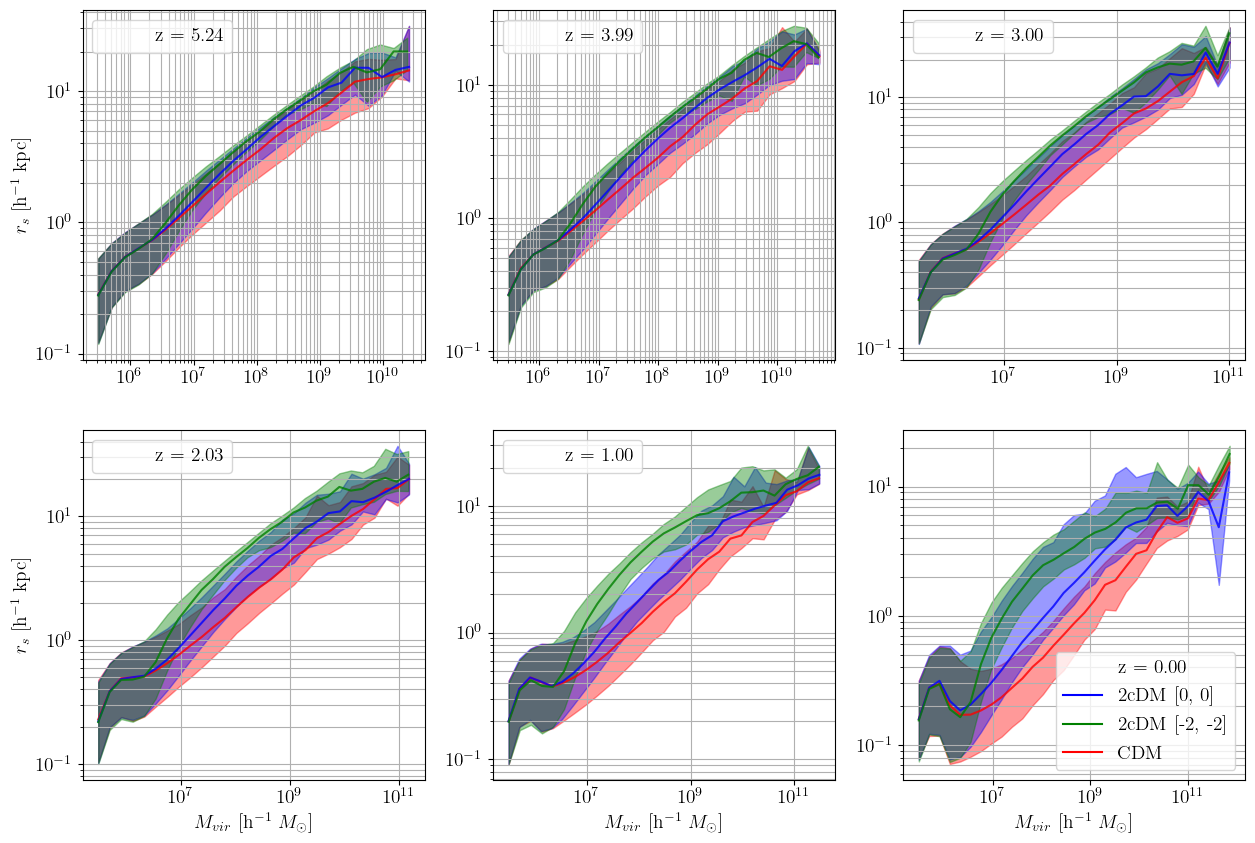

In [30]:
fig, ax = plt.subplots(2, 3, figsize=FIGSIZE)

for ar, snap_range in zip(ax, snap_ranges):
    for a, redshift in zip(ar, snap_range):

        cdm_m, cdm_med, cdm_10, cdm_90 = get_binned_stats(CDM_runs, redshift)

        tcdm_m, tcdm_med, tcdm_10, tcdm_90 = get_binned_stats(tcDM_runs1, redshift)

        twcdm_m, twcdm_med, twcdm_10, twcdm_90 = get_binned_stats(tcDM_runs2, redshift)

        a.plot(cdm_m, cdm_med, alpha=ALPHA, color=cdm_color)
        a.fill_between(cdm_m, cdm_10, cdm_90, alpha=0.5*ALPHA, color=cdm_color)

        a.plot(tcdm_m, tcdm_med, alpha=ALPHA, color=zz_color)
        a.fill_between(tcdm_m, tcdm_10, tcdm_90, alpha=0.5*ALPHA, color=zz_color)

        a.plot(twcdm_m, twcdm_med, alpha=ALPHA, color=m2m2_color)
        a.fill_between(twcdm_m, twcdm_10, twcdm_90, alpha=0.5*ALPHA, color=m2m2_color)

        r_nearest = cosmoSim(CDM_runs[0], base_path=base_path).get_nearest_redshift(redshift)


        a.set_yscale("log")
        a.set_xscale("log")
        # a.set_xlim(10**-2, 10**1)
        # a.set_ylim(10**-8, 10**1)
        a.grid(True, which="both", ls="-")
        a.set_aspect( 'auto', adjustable='box' )
        a.plot([],[], label=f'z = {r_nearest:.2f}', alpha=0)
        a.legend()


for ar in ax[1, :]:
    ar.set_xlabel('$M_{vir}$ [h$^{-1}$ $M_{\\odot}$]')

for ar in ax[:, 0]: 
    ar.set_ylabel("$r_s$ [h$^{-1}$ kpc]")

a = ax[-1,-1]
a.plot([],[], label='2cDM [0, 0]', color=zz_color)
a.plot([],[], label='2cDM [-2, -2]', color=m2m2_color)
a.plot([],[], label='CDM', color=cdm_color)

a.legend()
# fname = outpath + f'grid_SFR_mass.pdf'
# plt.savefig(fname, dpi=DPI, bbox_inches='tight')
plt.show()